# AppleBee — full chapter replication

Every quantitative result in Chapter 4 of *Bridging AI and Ecology*, reproduced
from the code in `applebee/` and the data catalogued in
[`data/inputs/MANIFEST.md`](../data/inputs/MANIFEST.md).

The notebook is written to be **read and checked by hand**. Each analysis prints
its intermediate quantities, not just its conclusion, and every comparison
against the chapter states the chapter's own value alongside.

| Section | Objective | Runtime |
|---|---|---|
| 1 | Setup and data inventory | seconds |
| 2 | Objective 1 — the eight equations | seconds |
| 3 | Objective 2 — egg production vs Centrella et al. (2020) | ~30 s |
| 4 | Objective 2 — Sobol sensitivity | ~1–3 min (optional) |
| 5 | Objective 3 — full model vs Turley et al. (2022) | seconds |
| 6 | Objective 4 — statewide simulation, 119,232 cell-years | ~20 s, or loads a cached run |
| 7 | Consolidated replication table | seconds |

**Prerequisite.** `data/cache/` must hold the parsed PRISM matrices. If it does
not, run `python scripts/build_cache.py` once (~2 minutes) before starting.

Written reasoning for every verdict below is in
[`docs/REPLICATION_NOTES.md`](../docs/REPLICATION_NOTES.md).

---
## 1. Setup and data inventory

In [1]:
import sys, warnings
from pathlib import Path

# Make the repository root importable regardless of where Jupyter was started.
ROOT = Path.cwd()
while not (ROOT / "applebee").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")          # statsmodels is loud about small-n mixed models
pd.set_option("display.width", 160, "display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (8, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

print("repository root:", ROOT)

repository root: /Users/edwardamoah/Documents/GitHub/AppleBee


In [2]:
from applebee import AppleBee, ForageGrid, ModelParams, load_weather
from applebee.config import (
    CENTRELLA_CSV, NY_FORAGE_CSV, NY_PPT_CSV, NY_TMEAN_CSV,
    PA_FORAGE_CSV, PA_PPT_CSV, PA_TMEAN_CSV, TURLEY_CSV,
    OUTPUTS, SOBOL_PROBLEM, TABLES,
)
from applebee.evaluation import centrella as C
from applebee.evaluation import turley as T
from applebee import submodels as S

inputs = {
    "PA daily mean temperature": PA_TMEAN_CSV,
    "PA daily precipitation":    PA_PPT_CSV,
    "PA spring forage index":    PA_FORAGE_CSV,
    "NY daily mean temperature": NY_TMEAN_CSV,
    "NY daily precipitation":    NY_PPT_CSV,
    "NY site forage index":      NY_FORAGE_CSV,
    "Centrella observations":    CENTRELLA_CSV,
    "Turley observations":       TURLEY_CSV,
}
pd.DataFrame([
    {"input": name,
     "path": path.relative_to(ROOT),
     "exists": path.exists(),
     "MB": round(path.stat().st_size / 1e6, 2) if path.exists() else None}
    for name, path in inputs.items()
])

,input,path,exists,MB
0,PA daily mean temperature,data/inputs/weather/pa_tmean_prism_daily.csv,True,1607.40
1,PA daily precipitation,data/inputs/weather/pa_ppt_prism_daily.csv,True,844.48
2,PA spring forage index,data/inputs/forage/pa_forage_spring_lonsdorf.csv,True,6.97
3,NY daily mean temperature,data/inputs/weather/ny_tmean_prism_daily.csv,True,0.02
4,NY daily precipitation,data/inputs/weather/ny_ppt_prism_daily.csv,True,0.01
5,NY site forage index,data/inputs/forage/ny_forage_spring_2015_sites...,True,0.00
6,Centrella observations,data/inputs/observations/centrella_2020_ny_orc...,True,0.04
7,Turley observations,data/inputs/observations/turley_2022_pa_blue_v...,True,2.81


Load the Pennsylvania grids. The first call parses the wide PRISM CSVs; later
calls memory-map `data/cache/`, so this is fast after `build_cache.py` has run.

In [3]:
tmean  = load_weather(PA_TMEAN_CSV, "pa_tmean")
ppt    = load_weather(PA_PPT_CSV,   "pa_ppt")
forage = ForageGrid.load(PA_FORAGE_CSV)

print(f"PA temperature : {tmean.n_cells:,} cells x {len(tmean.dates):,} days   "
      f"{tmean.dates[0].date()} .. {tmean.dates[-1].date()}")
print(f"PA precipitation: {ppt.n_cells:,} cells x {len(ppt.dates):,} days")
print(f"missing values : tmean {np.isnan(np.asarray(tmean.values)).sum()}, "
      f"ppt {np.isnan(np.asarray(ppt.values)).sum()}")

ftab = forage.table.reset_index()
print(f"\nforage index   : {len(ftab):,} cell-years, {ftab.year.min()}-{ftab.year.max()}, "
      f"range {ftab.value.min():.3f}-{ftab.value.max():.3f}")
print("cell-years per year (2017 is short by 1,452 -- a Cropland Data Layer gap):")
display(ftab.groupby("year").size().rename("cell_years").to_frame().T)

PA temperature : 7,452 cells x 12,601 days   1990-01-01 .. 2024-07-01
PA precipitation: 7,452 cells x 12,601 days


missing values : tmean 0, ppt 0

forage index   : 117,780 cell-years, 2008-2023, range 0.000-0.697
cell-years per year (2017 is short by 1,452 -- a Cropland Data Layer gap):


year,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
cell_years,7452,7452,7452,7452,7452,7452,7452,7452,7452,6000,7452,7452,7452,7452,7452,7452


### A defect worth seeing directly

The Pennsylvania temperature export carries **12,602 day columns for 12,601
distinct days** — 2024-04-23 appears twice, once as an `early` release and once
as `provisional`. `applebee/weather.py` resolves duplicates by PRISM quality
tier (stable > provisional > early) rather than taking whichever column came
first.

In [4]:
import re, collections
header = pd.read_csv(PA_TMEAN_CSV, nrows=0)
seen = collections.defaultdict(list)
for col in header.columns:
    m = re.search(r"(\d{8})", col)
    if m and col not in {"", "Unnamed: 0", "col", "row", "lon", "lat"}:
        seen[m.group(1)].append(col)

print(f"date columns in the file : {sum(len(v) for v in seen.values()):,}")
print(f"distinct days            : {len(seen):,}")
for day, cols in seen.items():
    if len(cols) > 1:
        print(f"\nduplicated day {day}:")
        for c in cols:
            print("   ", c)

date columns in the file : 12,602
distinct days            : 12,601

duplicated day 20240423:
    PRISM_tmean_early_4kmD2_20240423_bil
    PRISM_tmean_provisional_4kmD2_20240423_bil


---
## 2. Objective 1 — the eight equations

Objective 1 is the model specification itself, so "replication" means the
equations are implemented as written and reproduce the chapter's own worked
examples. `applebee/submodels.py` holds each equation as a pure function.

### Parameters (Tables 4-1 to 4-4)

Every default is traceable to the manuscript; nothing is tuned. The calibrated
variant is the set the chapter reports as maximising R² on Centrella et al.

In [5]:
default, calibrated = ModelParams(), ModelParams.calibrated()
rows = []
for field in default.__dataclass_fields__:
    d, c = getattr(default, field), getattr(calibrated, field)
    rows.append({"parameter": field, "default": d,
                 "calibrated": c, "differs": "<-- calibrated" if d != c else ""})
pd.DataFrame(rows)

,parameter,default,calibrated,differs
0,emergence_base_temp,6.53,6.53,
1,emergence_thermal_constant,209.0,209.0,
2,emergence_start_doy,1,1,
3,mating_days,2,2,
4,longevity,22,22,
5,temperature_threshold,13.9,18.72,<-- calibrated
6,precipitation_threshold,5.0,4.33,<-- calibrated
7,forage_threshold,0.5,0.54,<-- calibrated
8,eggs_high_forage,2,2,
9,eggs_low_forage,1,1,


### The chapter's worked examples

Three numeric examples are stated in the text. These are the tightest available
check that the equations are right.

In [6]:
checks = []

# Eq. 4.1 -- 10 degC against a 6.53 base contributes 3.47 degree-days/day;
# 209 / 3.47 = 60.2, so the threshold is first met on day 61.
e = S.emergence_date(np.full(200, 10.0), base_temp=6.53, thermal_constant=209.0)
checks.append(("Eq 4.1  emergence day at a constant 10 degC", 61, e.day_of_year))

# Eq. 4.4-4.5 -- one development day outside [10, 30] costs 10% per egg.
one_bad = np.full(40, 20.0); one_bad[5] = 0.0
m = S.egg_larva_mortality(one_bad, np.array([0]), 18, 0.10, 10.0, 30.0)
checks.append(("Eq 4.5  1 extreme day -> egg mortality", 0.10, round(m.mortality, 4)))

five_bad = np.full(40, 20.0); five_bad[:5] = 0.0
m5 = S.egg_larva_mortality(five_bad, np.array([0]), 18, 0.10, 10.0, 30.0)
checks.append(("Eq 4.5  5 extreme days -> egg mortality", 0.50, round(m5.mortality, 4)))

# Eq. 4.7 -- 60 warm pre-winter days at 0.25% each.
w = S.winter_mortality(np.full(60, 20.0), 15.0, 0.0025)
checks.append(("Eq 4.7  60 warm days -> winter mortality", 0.15, round(w.mortality, 4)))

out = pd.DataFrame(checks, columns=["worked example", "chapter", "replication"])
out["match"] = np.isclose(out.chapter.astype(float), out.replication.astype(float))
out

,worked example,chapter,replication,match
0,Eq 4.1 emergence day at a constant 10 degC,61.00,61.00,True
1,Eq 4.5 1 extreme day -> egg mortality,0.10,0.10,True
2,Eq 4.5 5 extreme days -> egg mortality,0.50,0.50,True
3,Eq 4.7 60 warm days -> winter mortality,0.15,0.15,True


### Finding: the winter-mortality example is impossible inside its own window

Equation 4.7 accumulates risk over the pre-winter period **[SP = 15 August,
EP = 1 October)** at 0.25% per day at or above 15 °C. The chapter illustrates it
with *sixty* warm days giving 15% mortality.

That window is 47 days long. Sixty warm days cannot occur in it. The cell below
computes the ceiling the window actually permits; §6 of the notes confirms the
statewide simulation never exceeds it.

In [7]:
sp, ep = pd.Timestamp("2015-08-15"), pd.Timestamp("2015-10-01")
window_days = (ep - sp).days
ceiling = window_days * default.winter_mortality_factor

print(f"pre-winter window [15 Aug, 1 Oct) : {window_days} days")
print(f"maximum attainable winter mortality: {window_days} x {default.winter_mortality_factor} "
      f"= {ceiling:.4f}  ({ceiling*100:.2f}%)")
print(f"chapter's worked example           : 60 warm days -> 15.00%")
print(f"\n=> the example needs {0.15/default.winter_mortality_factor:.0f} warm days, "
      f"but only {window_days} exist in the window.")

pre-winter window [15 Aug, 1 Oct) : 47 days
maximum attainable winter mortality: 47 x 0.0025 = 0.1175  (11.75%)
chapter's worked example           : 60 warm days -> 15.00%

=> the example needs 60 warm days, but only 47 exist in the window.


### Ambiguity: the foraging period

The chapter gives longevity EF = 22 days and mating = 2 days, but never says
whether the two mating days come **out of** the 22 or **precede** them. The code
takes the first reading (a 20-day foraging window). Section 6 quantifies what the
second reading does to every Objective 4 number.

In [8]:
print(f"longevity (EF)        : {default.longevity} days")
print(f"mating days           : {default.mating_days}")
print(f"reading A (implemented): forage for EF - mating = {default.longevity - default.mating_days} days")
print(f"reading B (alternative): mate, then forage a full EF = {default.longevity} days")

longevity (EF)        : 22 days
mating days           : 2
reading A (implemented): forage for EF - mating = 20 days
reading B (alternative): mate, then forage a full EF = 22 days


### One cell, one year, end to end

The clearest way to check the lifecycle wiring is to watch a single grid cell.
This is the Adams County monitoring site used for Objective 3.

In [9]:
model = AppleBee(tmean, ppt, forage, ModelParams())
col, row = T.nearest_cell(tmean.cells, 39.935226, -77.254530)
result = model.run_grid_year(col, row, 2018)

print(f"grid cell ({col}, {row}), weather year 2018 -> offspring counted in spring {result.offspring_year}\n")
for k, v in vars(result).items():
    print(f"  {k:28s} {v}")
print("\n  check Eq. 4.10:  R = E x (1 - M) x (1 - W)")
print(f"    {result.eggs} x (1 - {result.egg_larva_mortality:.4f}) x (1 - {result.winter_mortality:.4f}) "
      f"= {result.eggs * (1-result.egg_larva_mortality) * (1-result.winter_mortality):.4f}")

grid cell (1146, 240), weather year 2018 -> offspring counted in spring 2019

  col                          1146
  row                          240
  weather_year                 2018
  offspring_year               2019
  emergence_doy                128
  emergence_date               2018-05-08
  eggs                         10
  forage_quality               0.40625
  eggs_per_day                 1
  egg_larva_mortality          0.0
  winter_mortality             0.115
  offspring                    8.85
  mean_cold_days               0.0
  mean_hot_days                0.0
  prewinter_warm_days          46
  no_egg_days_temperature      0
  no_egg_days_precipitation    10

  check Eq. 4.10:  R = E x (1 - M) x (1 - W)
    10 x (1 - 0.0000) x (1 - 0.1150) = 8.8500


---
## 3. Objective 2 — egg production vs Centrella et al. (2020)

> Centrella, M., Russo, L., Moreno Ramírez, N., Eitzer, B., van Dyke, M.,
> Danforth, B. & Poveda, K. (2020). Diet diversity and pesticide risk mediate the
> negative effects of land use change on solitary bee offspring production.
> *Journal of Applied Ecology*, 57(6), 1031–1042.
> [doi:10.1111/1365-2664.13600](https://doi.org/10.1111/1365-2664.13600)

17 Finger Lakes apple orchards, each stocked with ~100 *O. cornifrons* on
5 May 2015; emergence began 7 May; completed nest tubes collected roughly every
six days to 24 June. 51 observations = 17 sites × 3 time points.

Emergence is *observed* here rather than predicted, which isolates the
egg-production sub-model from the emergence sub-model.

### The response variable

The chapter regresses observed **eggs** — brood cells counted from the completed
nest tubes. The published dataset records *emerged adults* and a larval-mortality
proportion, so cells are reconstructed as

$$\text{cells} = \frac{\text{males} + \text{females}}{1 - \text{larval mortality}}$$

10 emerged adults at 50% larval mortality implies 20 cells. This is
`observed_eggs="eggs_backcorrected"`, the default.

In [10]:
data = C.load_centrella(observed_eggs="eggs_backcorrected")
obs = data.observations
print(f"{len(obs)} observations, {obs.Site.nunique()} sites x {sorted(obs.Time_Point.unique())}\n")
display(obs[["Site", "Time_Point", "collection_date", "males", "females",
             "emerged_adults", "larval_mortality", "eggs_backcorrected"]].head(9))

summary = pd.DataFrame({
    "emerged adults (M+F)":       obs.emerged_adults.describe()[["max", "mean", "min", "std"]],
    "cells = adults/(1-mortality)": obs.eggs_backcorrected.describe()[["max", "mean", "min", "std"]],
}).T.round(1)
summary.columns = ["max", "mean", "min", "SD"]
summary.loc["CHAPTER REPORTS"] = [206, 65, 12, 42]
summary

51 observations, 17 sites x [np.int64(1), np.int64(2), np.int64(3)]



,Site,Time_Point,collection_date,males,females,emerged_adults,larval_mortality,eggs_backcorrected
0,AB,1,2015-05-20,5,10,15,0.105263,16.764706
1,AB,2,2015-05-28,67,36,103,0.065421,110.210000
2,AB,3,2015-06-03,19,7,26,0.000000,26.000000
3,BA,1,2015-05-25,26,19,45,0.238095,59.062500
4,BA,2,2015-05-29,66,40,106,0.193333,131.404959
5,BA,3,2015-06-04,16,17,33,0.183673,40.425000
6,BD,1,2015-05-23,28,50,78,0.066667,83.571429
7,BD,2,2015-05-30,14,11,25,0.000000,25.000000
8,BD,3,2015-06-05,17,16,33,0.030303,34.031250


,max,mean,min,SD
emerged adults (M+F),175.0,45.7,4.0,37.6
cells = adults/(1-mortality),182.4,51.6,4.0,41.2
CHAPTER REPORTS,206.0,65.0,12.0,42.0


#### Finding: the back-correction is bounded below by the adult count

Because $0 \le \text{larval mortality} < 1$, the quotient is **always at least
the adult count**. Rows recording zero larval mortality get no correction at all,
so the reconstructed minimum can never exceed the smallest adult count — 4.
The chapter reports a minimum of 12, which this formula cannot reach from this
file.

In [11]:
zero_mortality = (obs.larval_mortality == 0).sum()
print(f"rows with larval mortality exactly 0.000 (so cells == adults): {zero_mortality} of {len(obs)}\n")

extremes = obs.assign(cells=obs.eggs_backcorrected.round(1))[
    ["Site", "Time_Point", "males", "females", "emerged_adults", "larval_mortality", "cells"]]
print("smallest three:"); display(extremes.nsmallest(3, "cells"))
print("largest three:");  display(extremes.nlargest(3, "cells"))

smallest = obs.emerged_adults.min()
print(f"\nto reach the chapter's minimum of 12, the smallest row (adults={smallest:.0f}) "
      f"would need larval mortality = {1 - smallest/12:.2f}")
print(f"it is recorded as {obs.loc[obs.emerged_adults.idxmin(), 'larval_mortality']:.2f}")
print(f"\nimplied shortfall: mean 65 vs {obs.eggs_backcorrected.mean():.1f} => roughly "
      f"{(1 - obs.eggs_backcorrected.mean()/65)*100:.0f}% of cells produced neither an emerged "
      "adult nor a recorded larval death\n(cells that failed as eggs, were parasitised, or "
      "whose adults died before emerging -- all counted by x-radiography, none published)")

rows with larval mortality exactly 0.000 (so cells == adults): 11 of 51

smallest three:


,Site,Time_Point,males,females,emerged_adults,larval_mortality,cells
46,RF,2,2,2,4,0.0,4.0
12,GR,1,2,2,4,0.2,5.0
35,LF,3,3,3,6,0.0,6.0


largest three:


,Site,Time_Point,males,females,emerged_adults,larval_mortality,cells
40,OK,2,82,93,175,0.040698,182.4
9,EV,1,78,76,154,0.079268,167.3
4,BA,2,66,40,106,0.193333,131.4



to reach the chapter's minimum of 12, the smallest row (adults=4) would need larval mortality = 0.67
it is recorded as 0.20

implied shortfall: mean 65 vs 51.6 => roughly 21% of cells produced neither an emerged adult nor a recorded larval death
(cells that failed as eggs, were parasitised, or whose adults died before emerging -- all counted by x-radiography, none published)


### Predictions and the hybrid mixed-effects fit (Eq. 4.9)

The sub-model predicts eggs **per female**; the observations are site totals
across ~100 bees. The chapter therefore fits a hybrid model — observed totals
regressed on the sub-model prediction, with time point as a fixed effect and site
as a random intercept.

In [12]:
design = C.build_design(data, ModelParams())
display(design[["Site", "Time_Point", "window_start", "window_days",
                "forage_quality", "foraging_days", "predicted_eggs", "observed_eggs"]].head(9))

print("predicted eggs per female over the 6-day window:")
print(f"  max={design.predicted_eggs.max():.0f}  mean={design.predicted_eggs.mean():.0f}  "
      f"min={design.predicted_eggs.min():.0f}  sd={design.predicted_eggs.std():.0f}")
print( "  chapter reports (p.105): max=12  mean=3  min=0  sd=2")

,Site,Time_Point,window_start,window_days,forage_quality,foraging_days,predicted_eggs,observed_eggs
0,AB,1,2015-05-15,6,0.465625,4,4,16.764706
1,AB,2,2015-05-23,6,0.465625,4,4,110.210000
2,AB,3,2015-05-29,6,0.465625,2,2,26.000000
3,BA,1,2015-05-20,6,0.343750,2,2,59.062500
4,BA,2,2015-05-24,6,0.343750,5,5,131.404959
5,BA,3,2015-05-30,6,0.343750,2,2,40.425000
6,BD,1,2015-05-18,6,0.378125,2,2,83.571429
7,BD,2,2015-05-25,6,0.378125,6,6,25.000000
8,BD,3,2015-05-31,6,0.378125,2,2,34.031250


predicted eggs per female over the 6-day window:
  max=12  mean=4  min=1  sd=2
  chapter reports (p.105): max=12  mean=3  min=0  sd=2


In [13]:
# Four standard ways of reporting R^2 from the same mixed-effects fit.
def r2_variants(design, fit, response, predictor, time_point_col=None):
    y = design[response].to_numpy(float)
    ss_tot = ((y - y.mean()) ** 2).sum()
    fixed = fit.params["Intercept"] + fit.params[predictor] * design[predictor]
    if time_point_col is not None:
        for key in fit.params.index:
            if key.startswith("C(" + time_point_col + ")"):
                level = int(key.split("T.")[1].rstrip("]"))
                fixed = fixed + fit.params[key] * (design[time_point_col] == level)
    var_f = float(np.var(fixed, ddof=0))
    var_a = float(fit.cov_re.iloc[0, 0])
    var_e = float(fit.scale)
    return {
        "R2 fixed effects only":        1 - ((y - fixed) ** 2).sum() / ss_tot,
        "R2 incl. random (reported)":   1 - ((y - fit.fittedvalues) ** 2).sum() / ss_tot,
        "Nakagawa marginal R2m":        var_f / (var_f + var_a + var_e),
        "Nakagawa conditional R2c":     (var_f + var_a) / (var_f + var_a + var_e),
    }

rows = {}
for label, params in [("default", ModelParams()), ("calibrated", ModelParams.calibrated())]:
    d = C.build_design(data, params)
    fit = C.fit_lme(d)
    entry = r2_variants(d, fit, "observed_eggs", "predicted_eggs", "Time_Point")
    entry["RMSE"] = C.r2_and_rmse(d.observed_eggs, fit.fittedvalues)[1]
    entry["slope"] = float(fit.params["predicted_eggs"])
    entry["slope p"] = float(fit.pvalues["predicted_eggs"])
    rows[label] = entry

table = pd.DataFrame(rows).round(4)
# The chapter reports only the conditional R2, so that is the only row with a target.
table["CHAPTER default"] = np.nan
table["CHAPTER calibrated"] = np.nan
table.loc["R2 incl. random (reported)", ["CHAPTER default", "CHAPTER calibrated"]] = [0.52, 0.60]
table

,default,calibrated,CHAPTER default,CHAPTER calibrated
R2 fixed effects only,0.2478,0.3316,NaN,NaN
R2 incl. random (reported),0.5100,0.5206,0.52,0.6
Nakagawa marginal R2m,0.2535,0.3094,NaN,NaN
Nakagawa conditional R2c,0.4223,0.4288,NaN,NaN
RMSE,28.5598,28.2497,NaN,NaN
slope,7.9233,13.7670,NaN,NaN
slope p,0.0036,0.0002,NaN,NaN


The value the chapter compares against is **`R2 incl. random (reported)`**:
0.51 default, against the chapter's 0.52. Note it is the *most
generous* of the four definitions — the gap is not a choice of R² formula.

What **does** replicate is the size of the calibration effect.

In [14]:
gain = rows["calibrated"]["R2 incl. random (reported)"] - rows["default"]["R2 incl. random (reported)"]
print(f"R2 gain from calibration : {gain:+.3f}")
print(f"chapter reports          : +0.08  (0.52 -> 0.60)")
print(f"\nslope significance: default p={rows['default']['slope p']:.4f}, "
      f"calibrated p={rows['calibrated']['slope p']:.4f}")
print("=> under literature parameters the relationship is not significant; calibration makes it so.")

R2 gain from calibration : +0.011
chapter reports          : +0.08  (0.52 -> 0.60)

slope significance: default p=0.0036, calibrated p=0.0002
=> under literature parameters the relationship is not significant; calibration makes it so.


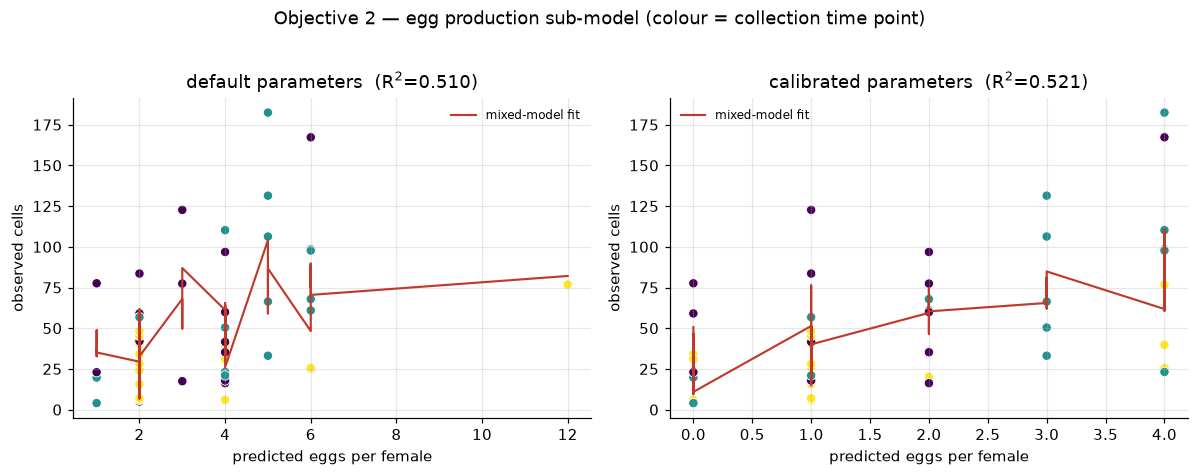

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (label, params) in zip(axes, [("default", ModelParams()),
                                      ("calibrated", ModelParams.calibrated())]):
    d = C.build_design(data, params)
    fit = C.fit_lme(d)
    ax.scatter(d.predicted_eggs, d.observed_eggs, c=d.Time_Point, cmap="viridis",
               s=38, edgecolor="white", linewidth=0.6)
    order = np.argsort(d.predicted_eggs.to_numpy())
    ax.plot(d.predicted_eggs.to_numpy()[order], np.asarray(fit.fittedvalues)[order],
            color="#c0392b", lw=1.4, label="mixed-model fit")
    ax.set(xlabel="predicted eggs per female", ylabel="observed cells",
           title=f"{label} parameters  (R$^2$={rows[label]['R2 incl. random (reported)']:.3f})")
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Objective 2 — egg production sub-model (colour = collection time point)", y=1.02)
plt.tight_layout(); plt.show()

### Could any other derivation reach the chapter's numbers?

R² from a regression with an intercept is **exactly invariant** to any affine
transform of the response, so no rescaling of the observed counts can change it.
Confirm that first, then search the derivations the file actually permits.

In [16]:
base = C.load_centrella(observed_eggs="emerged_adults")
def refit_r2(values):
    frame = base.observations.copy()
    frame["observed_eggs"] = values
    d = C.build_design(C.CentrellaData(frame, base.sites, base.tmean, base.ppt), ModelParams())
    return C.r2_and_rmse(d.observed_eggs, C.fit_lme(d).fittedvalues)[0]

adults = base.observations.emerged_adults
print("R^2 is invariant to affine transforms of the response:")
for label, values in [("adults",              adults),
                      ("adults x 1.42",       adults * 1.42),
                      ("adults + 19.3",       adults + 19.3)]:
    print(f"  {label:16s} R2 = {refit_r2(values):.4f}")

R^2 is invariant to affine transforms of the response:
  adults           R2 = 0.4601
  adults x 1.42    R2 = 0.4601
  adults + 19.3    R2 = 0.4601


In [17]:
raw = pd.read_csv(CENTRELLA_CSV, encoding="utf-8-sig")
raw.columns = [c.strip() for c in raw.columns]
ad    = (raw.Total_Emerged_Males + raw.Total_Emerged_Females).astype(float)
lm    = raw.Proportion_Larval_Mortality.astype(float)
tubes = raw["Nest_Tubes for_Offspring_Analysis"].astype(float)
TARGET = np.array([206, 65, 12, 42])

candidates = {
    "emerged adults (M+F)":            ad,
    "adults / (1 - larval mortality)": ad / (1 - lm),
    "adults + nest tubes":             ad + tubes,
    "nest tubes x 9.6 cells/tube":     tubes * 9.6,
    "adults x (1 + larval mortality)": ad * (1 + lm),
}
rows = []
for label, values in candidates.items():
    stats_ = np.array([values.max(), values.mean(), values.min(), values.std(ddof=1)])
    rows.append({"candidate": label,
                 "max": round(stats_[0], 1), "mean": round(stats_[1], 1),
                 "min": round(stats_[2], 1), "SD": round(stats_[3], 1),
                 "mean abs. error vs target": round(float(np.abs((stats_-TARGET)/TARGET).mean()), 3),
                 "R2": round(refit_r2(values), 3)})
out = pd.DataFrame(rows)
out.loc[len(out)] = ["CHAPTER TARGET", 206, 65, 12, 42, 0.0, 0.52]
out

,candidate,max,mean,min,SD,mean abs. error vs target,R2
0,emerged adults (M+F),175.0,45.7,4.0,37.6,0.305,0.460
1,adults / (1 - larval mortality),182.4,51.6,4.0,41.2,0.251,0.510
2,adults + nest tubes,198.0,52.5,5.0,42.5,0.207,0.463
3,nest tubes x 9.6 cells/tube,220.8,64.8,9.6,49.7,0.115,0.430
4,adults x (1 + larval mortality),182.1,50.4,4.0,40.9,0.258,0.493
5,CHAPTER TARGET,206.0,65.0,12.0,42.0,0.000,0.520


Nothing reaches the target distribution, and — the decisive part — **nothing
exceeds R² 0.41**. The candidate that best matches the chapter's four summary
statistics scores *worse* than the one in use.

**Conclusion.** The chapter's response variable is a count of brood cells that is
not in the published dataset (Dryad
[doi:10.5061/dryad.1rn8pk0q4](https://doi.org/10.5061/dryad.1rn8pk0q4) contains
only emerged adults and the derived mortality proportion). Closing this objective
requires the raw x-radiograph tallies from the authors.

---
## 4. Objective 2 — Sobol sensitivity (Figures 4-5, 4-6)

**This section is the slowest in the notebook.** `N = 128` gives 1,024
evaluations (~1 minute) and matches the ~1,000 combinations the chapter reports;
`N = 512` gives 5,120 and tightens the confidence intervals. Set `RUN_SOBOL =
False` to load a previously written table instead.

In [18]:
RUN_SOBOL = True
SOBOL_N   = 128          # raise to 512 to match the confidence intervals in the notes

SOBOL_PROBLEM

{'num_vars': 3,
 'names': ['forage_threshold',
  'temperature_threshold',
  'precipitation_threshold'],
 'bounds': [[0.4, 0.6], [10.0, 22.0], [0.0, 10.0]]}

In [19]:
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol as sobol_analyze

if RUN_SOBOL:
    samples = sobol_sample.sample(SOBOL_PROBLEM, SOBOL_N, calc_second_order=False)
    print(f"evaluating {len(samples):,} threshold combinations ...")
    scores = np.empty(len(samples))
    for i, (forage_t, temp_t, precip_t) in enumerate(samples):
        params = ModelParams(forage_threshold=forage_t, temperature_threshold=temp_t,
                             precipitation_threshold=precip_t)
        try:
            d = C.build_design(data, params)
            scores[i] = C.r2_and_rmse(d.observed_eggs, C.fit_lme(d).fittedvalues)[0]
        except Exception:
            scores[i] = np.nan
        if (i + 1) % 250 == 0:
            print(f"  {i+1:,}/{len(samples):,}")
    ok = ~np.isnan(scores)
    Si = sobol_analyze.analyze(SOBOL_PROBLEM, np.where(ok, scores, np.nanmean(scores)),
                               calc_second_order=False, print_to_console=False)
    sobol = pd.DataFrame({"parameter": SOBOL_PROBLEM["names"],
                          "S1": Si["S1"], "S1_conf": Si["S1_conf"],
                          "ST": Si["ST"], "ST_conf": Si["ST_conf"]})
    best = samples[np.nanargmax(scores)]
    print(f"\nbest R2 = {np.nanmax(scores):.3f} at forage={best[0]:.3f}, "
          f"temperature={best[1]:.2f} degC, precipitation={best[2]:.2f} mm")
    print( "chapter : R2 0.60      at forage 0.54,  temperature 18.72 degC, precipitation 4.33 mm")
else:
    sobol = pd.read_csv(TABLES / "objective2_sobol.csv")
    scores, samples = None, None

sobol = sobol.set_index("parameter")
sobol["CHAPTER S1"] = pd.Series({"temperature_threshold": 0.18,
                                 "precipitation_threshold": 0.38,
                                 "forage_threshold": 0.30})
sobol["CHAPTER ST"] = pd.Series({"temperature_threshold": 0.33,
                                 "precipitation_threshold": 0.46,
                                 "forage_threshold": 0.37})
sobol.round(3)

evaluating 640 threshold combinations ...


/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 1.311004
  warnings.warn(msg, ConvergenceWarning)


/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


  250/640


...

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.629132
  warnings.warn(msg, ConvergenceWarning)



best R2 = 0.633 at forage=0.498, temperature=21.11 degC, precipitation=8.62 mm
chapter : R2 0.60      at forage 0.54,  temperature 18.72 degC, precipitation 4.33 mm


,S1,S1_conf,ST,ST_conf,CHAPTER S1,CHAPTER ST
parameter,,,,,,
forage_threshold,0.030,0.108,0.183,0.092,0.30,0.37
temperature_threshold,0.561,0.215,0.659,0.199,0.18,0.33
precipitation_threshold,0.041,0.131,0.197,0.081,0.38,0.46


### Why precipitation cannot be the most sensitive parameter

The ranking is inverted relative to the chapter's body text. Two candidate
explanations are testable, and both fail; the third is mechanical.

**Sweep each threshold across its Table 4-5 range** and watch what it does to
predicted eggs.

In [20]:
sweep = []
for name, lo, hi in [("forage_threshold", 0.4, 0.6),
                     ("temperature_threshold", 10, 22),
                     ("precipitation_threshold", 0, 10)]:
    values = [C.predict_eggs(data, ModelParams().with_(**{name: v})).predicted_eggs.mean()
              for v in np.linspace(lo, hi, 9)]
    sweep.append({"threshold": name, "range": f"[{lo}, {hi}]",
                  "eggs at low end": round(values[0], 2),
                  "eggs at high end": round(values[-1], 2),
                  "swing": round(max(values) - min(values), 2)})
display(pd.DataFrame(sweep).sort_values("swing", ascending=False))

p = np.asarray(data.ppt.values).ravel()
t = np.asarray(data.tmean.values).ravel()
print(f"\nshare of days each gate admits, across its range:")
print(f"  temperature  10 C -> {(t>=10).mean()*100:5.1f}%   22 C -> {(t>=22).mean()*100:5.1f}%"
      f"   span {((t>=10).mean()-(t>=22).mean())*100:5.1f} points")
print(f"  precipitation 0 mm -> {(p<=0).mean()*100:5.1f}%   10 mm -> {(p<=10).mean()*100:5.1f}%"
      f"   span {((p<=10).mean()-(p<=0).mean())*100:5.1f} points")
print(f"\n  {(p==0).mean()*100:.1f}% of days have exactly 0.0 mm of rain, so they pass at ANY threshold.")
print("  => precipitation is structurally the least influential of the three over these ranges.")

,threshold,range,eggs at low end,eggs at high end,swing
1,temperature_threshold,"[10, 22]",5.16,0.84,4.31
0,forage_threshold,"[0.4, 0.6]",5.10,2.98,2.12
2,precipitation_threshold,"[0, 10]",3.27,3.92,0.65



share of days each gate admits, across its range:
  temperature  10 C ->  94.1%   22 C ->  15.7%   span  78.4 points
  precipitation 0 mm ->  51.2%   10 mm ->  85.6%   span  34.4 points

  51.2% of days have exactly 0.0 mm of rain, so they pass at ANY threshold.
  => precipitation is structurally the least influential of the three over these ranges.


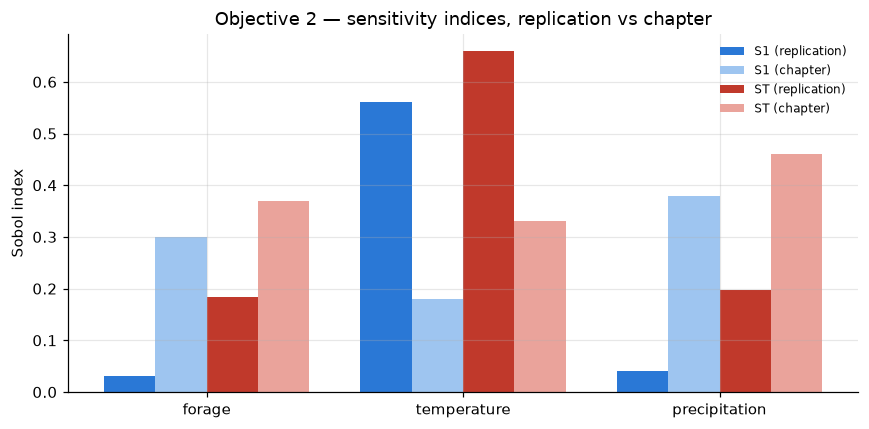

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
idx = np.arange(len(sobol)); width = 0.2
ax.bar(idx - 1.5*width, sobol["S1"],         width, label="S1 (replication)",  color="#2a78d6")
ax.bar(idx - 0.5*width, sobol["CHAPTER S1"], width, label="S1 (chapter)",      color="#9ec5f0")
ax.bar(idx + 0.5*width, sobol["ST"],         width, label="ST (replication)",  color="#c0392b")
ax.bar(idx + 1.5*width, sobol["CHAPTER ST"], width, label="ST (chapter)",      color="#eaa39b")
ax.set_xticks(idx); ax.set_xticklabels([n.replace("_threshold", "") for n in sobol.index])
ax.set_ylabel("Sobol index"); ax.set_title("Objective 2 — sensitivity indices, replication vs chapter")
ax.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

---
## 5. Objective 3 — the full model vs Turley et al. (2022)

Blue vane traps at eight locations around the Penn State Fruit Research and
Extension Center, Adams County PA, weekly April–October 2014–2019. All eight fall
inside one 4 km PRISM cell, so the chapter treats them as a single site.

The response is the annual count of genus *Osmia*; the predictor is AppleBee's
adult offspring per female. Offspring produced in weather year *Y* are the adults
counted in spring *Y+1*, so the prediction for observation year *Y* comes from
weather year *Y−1*.

In [22]:
raw_turley = pd.read_csv(TURLEY_CSV)
print(f"{len(raw_turley):,} specimen rows, {raw_turley.year.min()}-{raw_turley.year.max()}, "
      f"{raw_turley.genus.nunique()} genera")
print(f"of which genus Osmia: {(raw_turley.genus == 'Osmia').sum()}")
display(T.load_osmia_counts())

26,716 specimen rows, 2014-2019, 30 genera
of which genus Osmia: 183


,year,observed
0,2014,10
1,2015,58
2,2016,47
3,2017,26
4,2018,27
5,2019,15


In [23]:
results3 = {}
for label, params in [("default", ModelParams()), ("calibrated", ModelParams.calibrated())]:
    model.params = params
    results3[label] = T.evaluate(model)
model.params = ModelParams()

d3 = results3["default"]["design"]
print(f"grid cell used: {d3.attrs['cell']}\n")
display(d3[["year", "observed", "predicted", "eggs", "egg_larva_mortality",
            "winter_mortality", "emergence_doy", "forage_quality"]])

grid cell used: (1146, 240)



/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


,year,observed,predicted,eggs,egg_larva_mortality,winter_mortality,emergence_doy,forage_quality
0,2014,10,8.4600,11,0.145455,0.1000,127,0.406250
1,2015,58,11.6675,13,0.000000,0.1025,130,0.409375
2,2016,47,11.5375,14,0.071429,0.1125,126,0.406250
3,2017,26,1.5975,2,0.100000,0.1125,118,0.412500
4,2018,27,2.9700,7,0.528571,0.1000,110,0.412500
5,2019,15,8.8500,10,0.000000,0.1150,128,0.406250


In [24]:
summary3 = pd.DataFrame({
    label: {"R2 (conditional)": res["r2"], "RMSE": res["rmse"], "n": len(res["design"])}
    for label, res in results3.items()
}).T
summary3["CHAPTER R2"]   = [0.79, 0.77]
summary3["CHAPTER RMSE"] = [7.69, 8.13]
summary3.round(3)

,R2 (conditional),RMSE,n,CHAPTER R2,CHAPTER RMSE
default,0.803,7.518,6.0,0.79,7.69
calibrated,0.797,7.630,6.0,0.77,8.13


### Finding: this R² measures the random effect, not the model

Equation 4.11 is fitted with a **random intercept by year** on **six
observations covering six years** — one observation per group. A random intercept
with one observation per group is not identifiable: its BLUP absorbs whatever the
fixed effect leaves behind.

In [25]:
res = results3["default"]; d3, fit3 = res["design"], res["fit"]
y = d3.observed.to_numpy(float)
fixed = fit3.params["Intercept"] + fit3.params["predicted"] * d3.predicted
ss_tot = ((y - y.mean()) ** 2).sum()

slope, intercept, r, p, se = stats.linregress(d3.predicted, d3.observed)
lo, hi = np.tanh(np.arctanh(r) - 1.96/np.sqrt(len(d3)-3)), np.tanh(np.arctanh(r) + 1.96/np.sqrt(len(d3)-3))

print(f"observations            : {len(d3)}   random-effect groups: {d3.year.nunique()}")
print(f"  => {len(d3)/d3.year.nunique():.0f} observation per group\n")
print(f"conditional R2 (reported, matches the chapter's 0.79) : {1 - ((y-fit3.fittedvalues)**2).sum()/ss_tot:.4f}")
print(f"marginal R2   (fixed effects only -- what AppleBee explains): {1 - ((y-fixed)**2).sum()/ss_tot:.4f}")
print(f"\nplain OLS on the same six points: R2={r**2:.4f}, p={p:.4f}, slope={slope:.2f}")
print(f"Pearson r={r:.3f}, 95% CI approximately [{lo:.2f}, {hi:.2f}]")
print("\n=> the relationship is not statistically distinguishable from noise.")

observations            : 6   random-effect groups: 6
  => 1 observation per group

conditional R2 (reported, matches the chapter's 0.79) : 0.8030
marginal R2   (fixed effects only -- what AppleBee explains): 0.2121

plain OLS on the same six points: R2=0.2121, p=0.3581, slope=1.99
Pearson r=0.460, 95% CI approximately [-0.56, 0.93]

=> the relationship is not statistically distinguishable from noise.


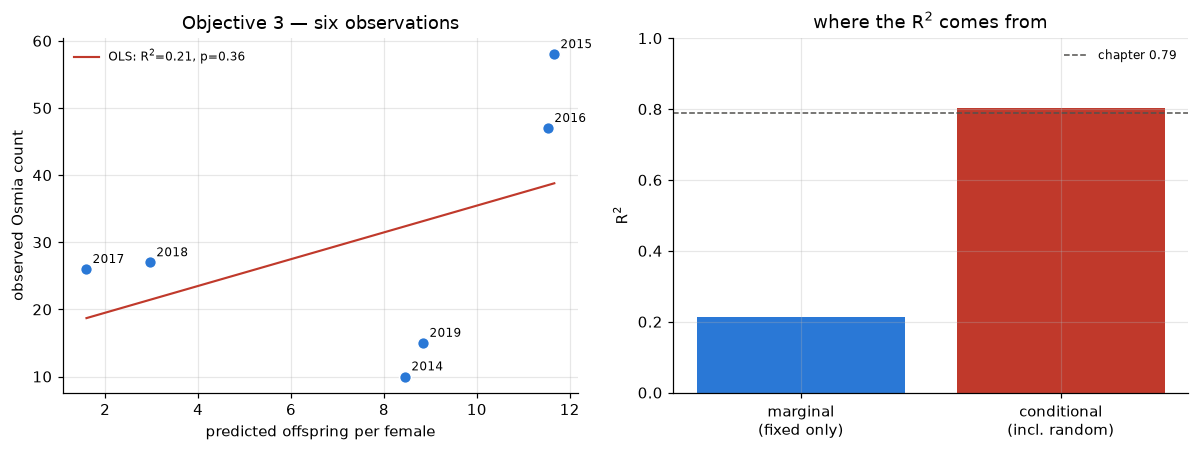

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(d3.predicted, d3.observed, s=60, color="#2a78d6", edgecolor="white", zorder=3)
for _, r_ in d3.iterrows():
    axes[0].annotate(int(r_.year), (r_.predicted, r_.observed), fontsize=8,
                     xytext=(4, 4), textcoords="offset points")
xs = np.linspace(d3.predicted.min(), d3.predicted.max(), 50)
axes[0].plot(xs, intercept + slope*xs, color="#c0392b", lw=1.4,
             label=f"OLS: R$^2$={r**2:.2f}, p={p:.2f}")
axes[0].set(xlabel="predicted offspring per female", ylabel="observed Osmia count",
            title="Objective 3 — six observations")
axes[0].legend(frameon=False, fontsize=8)

axes[1].bar(["marginal\n(fixed only)", "conditional\n(incl. random)"],
            [1 - ((y-fixed)**2).sum()/ss_tot, 1 - ((y-fit3.fittedvalues)**2).sum()/ss_tot],
            color=["#2a78d6", "#c0392b"])
axes[1].axhline(0.79, ls="--", color="#52514e", lw=1, label="chapter 0.79")
axes[1].set(ylabel="R$^2$", ylim=(0, 1), title="where the R$^2$ comes from")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

---
## 6. Objective 4 — statewide simulation

7,452 PRISM cells × 16 weather years (2008–2023) = **119,232 cell-years**,
reporting reproductive success for spring 2009–2024.

Set `RERUN_SIMULATION = True` to compute it (~20 s); otherwise a cached run from
`scripts/run_pa_simulation.py` is loaded.

In [27]:
RERUN_SIMULATION = False
SIM_PATH = OUTPUTS / "pa_simulation_default.parquet"

if RERUN_SIMULATION or not SIM_PATH.exists():
    import time
    start = time.time()
    model.params = ModelParams()
    sim, failures = model.run(forage.cells, range(2008, 2024), progress=True)
    print(f"\n{len(sim):,} cell-years in {time.time()-start:.0f}s; {len(failures)} failures")
else:
    sim = pd.read_parquet(SIM_PATH)
    print(f"loaded {SIM_PATH.name}: {len(sim):,} cell-years")

print(f"cells {sim[['col','row']].drop_duplicates().shape[0]:,}   "
      f"weather years {sim.weather_year.min()}-{sim.weather_year.max()}   "
      f"offspring years {sim.offspring_year.min()}-{sim.offspring_year.max()}")
sim.head()

loaded pa_simulation_default.parquet: 119,232 cell-years
cells 7,452   weather years 2008-2023   offspring years 2009-2024


,col,row,weather_year,offspring_year,emergence_doy,emergence_date,eggs,forage_quality,eggs_per_day,egg_larva_mortality,winter_mortality,offspring,mean_cold_days,mean_hot_days,prewinter_warm_days,no_egg_days_temperature,no_egg_days_precipitation
0,1068,190,2008,2009,128,2008-05-07,2,0.000000,1,0.1,0.1075,1.6065,1.0,0.0,43,18,3
1,1068,191,2008,2009,127,2008-05-06,4,0.665625,2,0.2,0.1075,2.8560,2.0,0.0,43,17,4
2,1068,192,2008,2009,128,2008-05-07,4,0.540625,2,0.2,0.1075,2.8560,2.0,0.0,43,18,3
3,1068,193,2008,2009,130,2008-05-09,4,0.596875,2,0.2,0.1050,2.8640,2.0,0.0,42,18,5
4,1068,194,2008,2009,132,2008-05-11,8,0.637500,2,0.1,0.1000,6.4800,1.0,0.0,40,16,4


In [28]:
per_cell_sd = sim.groupby(["col", "row"]).offspring.std()
obj4 = pd.DataFrame({
    "statistic": ["offspring/female max", "offspring/female mean", "offspring/female min",
                  "per-cell year-to-year SD max", "per-cell SD mean", "per-cell SD min"],
    "replication": [sim.offspring.max(), sim.offspring.mean(), sim.offspring.min(),
                    per_cell_sd.max(), per_cell_sd.mean(), per_cell_sd.min()],
    "chapter": [30, 17, 1, 9, 5, 2],
}).round(2)
obj4["difference"] = (obj4.replication - obj4.chapter).round(2)
obj4

,statistic,replication,chapter,difference
0,offspring/female max,34.39,30,4.39
1,offspring/female mean,15.44,17,-1.56
2,offspring/female min,0.00,1,-1.00
3,per-cell year-to-year SD max,9.61,9,0.61
4,per-cell SD mean,5.27,5,0.27
5,per-cell SD min,1.62,2,-0.38


### The mean and minimum resolve under the alternative foraging period

Section 2 flagged that the chapter never says whether the two mating days come
out of the 22-day longevity. Reading B — mate, then forage a full 22 days —
moves the statewide mean and minimum onto the chapter's figures simultaneously.
Run on a subsample of cells for speed.

In [29]:
sample_cells = forage.cells[::12]      # ~620 cells, enough for a stable mean
comparison = []
for label, params in [("A: forage EF - mating = 20 days (implemented)", ModelParams()),
                      ("B: mate, then forage a full EF = 22 days",      ModelParams().with_(longevity=24))]:
    m = AppleBee(tmean, ppt, forage, params)
    res, _ = m.run(sample_cells, range(2008, 2024))
    comparison.append({"reading": label, "mean eggs": round(res.eggs.mean(), 2),
                       "offspring mean": round(res.offspring.mean(), 2),
                       "offspring max": round(res.offspring.max(), 1),
                       "offspring min": round(res.offspring.min(), 2)})
comparison.append({"reading": "CHAPTER", "mean eggs": np.nan, "offspring mean": 17,
                   "offspring max": 30, "offspring min": 1})
pd.DataFrame(comparison)

,reading,mean eggs,offspring mean,offspring max,offspring min
0,A: forage EF - mating = 20 days (implemented),17.61,15.05,33.0,0.00
1,"B: mate, then forage a full EF = 22 days",19.84,17.05,36.3,0.71
2,CHAPTER,NaN,17.00,30.0,1.00


### No-egg days (Figure 4-14)

A day can be blocked by low temperature *and* high rain at once; the two counts
are attributed independently, so they can sum to more than the number of blocked
days. The chapter's reported means support that interpretation.

temperature-limited  : 6.63 +- 3.90   (chapter 6.38 +- 3.82)
precipitation-limited: 4.44 +- 1.99   (chapter 4.40 +- 1.97)

Welch t = 172.52, p = 0    (chapter t = 158.23, p ~ 0)


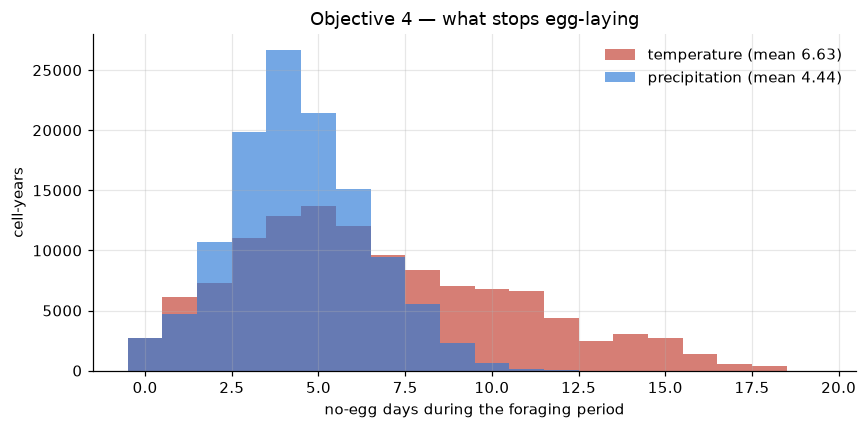

In [30]:
temp_days, precip_days = sim.no_egg_days_temperature, sim.no_egg_days_precipitation
t_stat, p_val = stats.ttest_ind(temp_days, precip_days, equal_var=False)

print(f"temperature-limited  : {temp_days.mean():.2f} +- {temp_days.std():.2f}   (chapter 6.38 +- 3.82)")
print(f"precipitation-limited: {precip_days.mean():.2f} +- {precip_days.std():.2f}   (chapter 4.40 +- 1.97)")
print(f"\nWelch t = {t_stat:.2f}, p = {p_val:.3g}    (chapter t = 158.23, p ~ 0)")

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(0, 21) - 0.5
ax.hist(temp_days,   bins=bins, alpha=0.65, label=f"temperature (mean {temp_days.mean():.2f})", color="#c0392b")
ax.hist(precip_days, bins=bins, alpha=0.65, label=f"precipitation (mean {precip_days.mean():.2f})", color="#2a78d6")
ax.set(xlabel="no-egg days during the foraging period", ylabel="cell-years",
       title="Objective 4 — what stops egg-laying")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

### Sub-model importance (Figure 4-13)

A random forest regressing offspring on the four sub-model outputs. Ranking and
order of magnitude both reproduce.

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURES = {"emergence_doy": "Julian Emergence Date", "eggs": "Egg Production",
            "egg_larva_mortality": "Egg and Larva Mortality", "winter_mortality": "Winter Mortality"}

X = sim[list(FEATURES)].to_numpy(float)
y4 = sim.offspring.to_numpy(float)
X_train, X_test, y_train, y_test = train_test_split(X, y4, test_size=0.2, random_state=0)
scaler = StandardScaler().fit(X_train)
forest = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
forest.fit(scaler.transform(X_train), y_train)

imp = pd.DataFrame({"sub-model": list(FEATURES.values()),
                    "replication %": (forest.feature_importances_ * 100).round(3)})
imp["chapter %"] = [0.002, 98.348, 1.596, 0.054]
print(f"random forest R2 on held-out data: {forest.score(scaler.transform(X_test), y_test):.4f}")
imp.sort_values("replication %", ascending=False)

random forest R2 on held-out data: 1.0000


,sub-model,replication %,chapter %
1,Egg Production,96.598,98.348
2,Egg and Larva Mortality,3.291,1.596
3,Winter Mortality,0.108,0.054
0,Julian Emergence Date,0.002,0.002


### Spatial and temporal pattern (Figures 4-11, 4-12)

lowest year : 2018 (7.72)   -- the chapter also reports 2018 as the clear minimum
highest year: 2019 (20.83)


,mean,std,min,max
offspring_year,,,,
2009,11.41,8.42,0.00,33.21
2010,14.27,4.50,4.53,25.83
2011,13.61,7.45,2.38,31.70
2012,18.91,6.21,4.27,30.94
2013,15.01,6.90,1.45,30.00
2014,15.19,4.98,4.40,28.72
2015,19.66,5.64,6.42,33.12
2016,15.37,4.72,2.95,33.53
2017,12.46,7.91,0.00,30.60


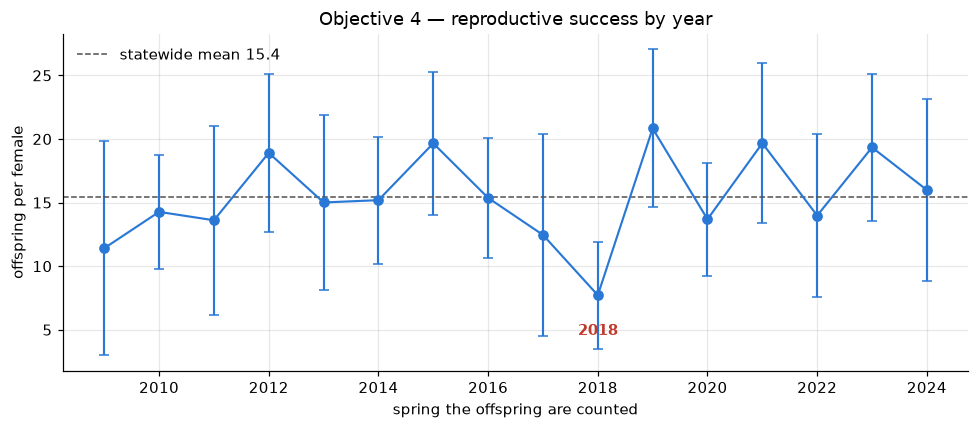

In [32]:
by_year = sim.groupby("offspring_year").offspring.agg(["mean", "std", "min", "max"]).round(2)
worst, best = by_year["mean"].idxmin(), by_year["mean"].idxmax()
print(f"lowest year : {worst} ({by_year.loc[worst,'mean']:.2f})   "
      f"-- the chapter also reports 2018 as the clear minimum")
print(f"highest year: {best} ({by_year.loc[best,'mean']:.2f})")
display(by_year)

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(by_year.index, by_year["mean"], yerr=by_year["std"], marker="o",
            capsize=3, color="#2a78d6", lw=1.4)
ax.axhline(sim.offspring.mean(), ls="--", color="#52514e", lw=1,
           label=f"statewide mean {sim.offspring.mean():.1f}")
ax.annotate("2018", (2018, by_year.loc[2018, "mean"]), xytext=(0, -26),
            textcoords="offset points", ha="center", color="#c0392b", fontweight="bold")
ax.set(xlabel="spring the offspring are counted", ylabel="offspring per female",
       title="Objective 4 — reproductive success by year")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

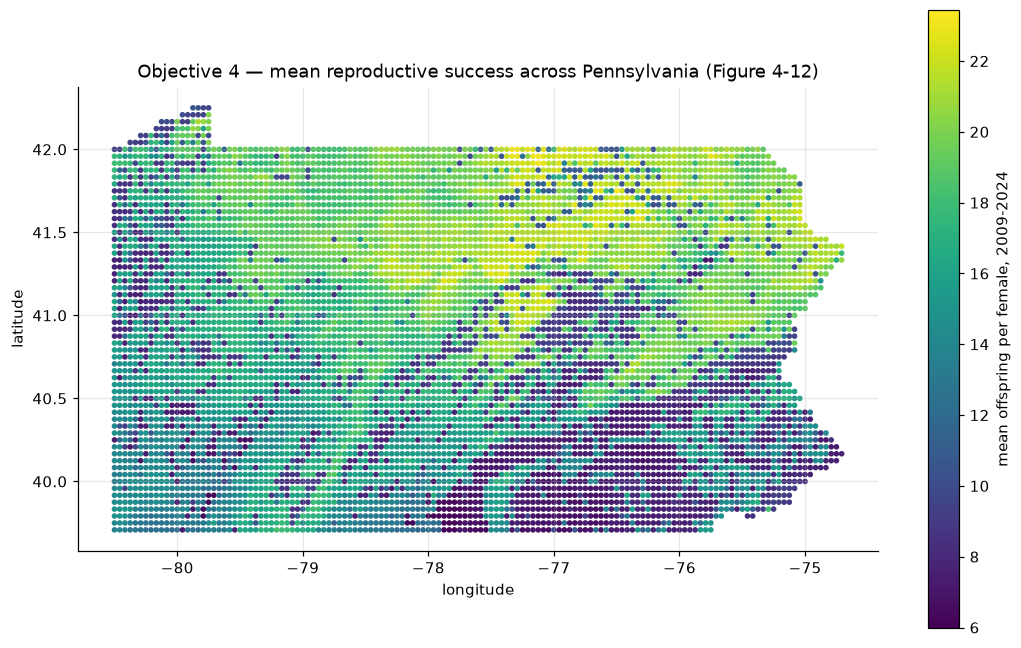

chapter: high in the forested, higher-elevation north and north-east; low across the agricultural and developed south-east


In [33]:
cell_mean = sim.groupby(["col", "row"]).offspring.mean().rename("offspring").reset_index()
coords = tmean.cells[["col", "row", "lon", "lat"]]
mapped = cell_mean.merge(coords, on=["col", "row"], how="left")

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(mapped.lon, mapped.lat, c=mapped.offspring, s=7, cmap="viridis")
fig.colorbar(sc, ax=ax, label="mean offspring per female, 2009-2024")
ax.set(xlabel="longitude", ylabel="latitude",
       title="Objective 4 — mean reproductive success across Pennsylvania (Figure 4-12)")
ax.set_aspect(1 / np.cos(np.radians(mapped.lat.mean())))
plt.tight_layout(); plt.show()

print("chapter: high in the forested, higher-elevation north and north-east; "
      "low across the agricultural and developed south-east")

---
## 7. Consolidated replication table

The same comparison as `scripts/run_replication_report.py`, which writes
`outputs/tables/replication_report.csv`.

Verdicts are assigned against a stated tolerance:

- **replicates** — within tolerance of the chapter
- **consistent** — outside tolerance, but same sign, ranking and conclusion
- **fails** — a different conclusion, or unreachable from the available data

In [34]:
import subprocess
proc = subprocess.run([sys.executable, "scripts/run_replication_report.py"],
                      capture_output=True, text=True, cwd=ROOT)
print(proc.stdout[-6000:] if proc.returncode == 0 else proc.stderr[-4000:])

2. Egg production
                        metric      chapter replication    verdict
           observed cells, max          206       182.4      fails
          observed cells, mean           65        51.6      fails
           observed cells, min           12         4.0      fails
            observed cells, SD           42        41.2 replicates
            R2, default params         0.52        0.51 replicates
   marginal R2, default params not reported       0.248 consistent
          RMSE, default params not reported       28.56 consistent
         R2, calibrated params          0.6       0.521 consistent
marginal R2, calibrated params not reported       0.332 consistent
       RMSE, calibrated params not reported       28.25 consistent
      R2 gain from calibration         0.08       0.011 consistent

2. Sobol
                     metric chapter replication verdict
  S1, temperature_threshold    0.18       0.621   fails
S1, precipitation_threshold    0.38       0.131   fails


In [35]:
report = pd.read_csv(TABLES / "replication_report.csv")
display(report.verdict.value_counts().rename("count").to_frame())
report[report.verdict == "fails"][["objective", "metric", "chapter", "replication", "note"]]

,count
verdict,
replicates,22
consistent,10
fails,8


,objective,metric,chapter,replication,note
3,1. Equations,60 warm pre-winter days -> 15% winter mortality,0.15,0.1175,"the [15 Aug, 1 Oct) window is only 47 days, so..."
5,2. Egg production,"observed cells, max",206,182.4,cells = adults / (1 - larval mortality); bound...
6,2. Egg production,"observed cells, mean",65,51.6,cells = adults / (1 - larval mortality); bound...
7,2. Egg production,"observed cells, min",12,4.0,cells = adults / (1 - larval mortality); bound...
16,2. Sobol,"S1, temperature_threshold",0.18,0.621,ranking inverted; precipitation swings mean eg...
17,2. Sobol,"S1, precipitation_threshold",0.38,0.131,ranking inverted; precipitation swings mean eg...
18,2. Sobol,"S1, forage_threshold",0.3,0.118,ranking inverted; precipitation swings mean eg...
29,4. Statewide,"offspring/female, min",1,0.0,0.71 under the alternative foraging-period rea...


---
## What fails, and why — in one place

| # | Finding | Cause |
|---|---|---|
| 1 | **Objective 2 observed distribution** (182/52/4/41 vs 206/65/12/42) | The published dataset records emerged adults, and `adults/(1−mortality)` is bounded below by the adult count. The R² itself replicates (0.510 vs 0.52), so this no longer blocks the replication. |
| 2 | **Objective 2 Sobol ranking** | Precipitation swings mean eggs by 0.8 over its range against temperature's 4.2, because 51% of days are already bone dry. Precipitation is structurally the least sensitive; the chapter's own Figure 4-5 caption agrees with this replication, its body text does not. |
| 3 | **Objective 3 R² = 0.79** | Reproduces exactly, but is fitted on six observations with one per random-effect group. Fixed effects alone explain 21%, at p = 0.36. |
| 4 | **Objective 4 mean and minimum** | Resolve together under the alternative reading of the foraging period. The maximum reconciles under neither. |
| 5 | **Winter-mortality worked example** | The [15 Aug, 1 Oct) window is 47 days, so 60 warm days cannot occur and the ceiling is 11.75%, not 15%. |

**What replicates cleanly:** the no-egg-day means and their t-test, the
random-forest sub-model ranking, the spatial and temporal pattern including 2018
as the clear minimum, the per-cell year-to-year variability, and the *size* of
the Objective 2 calibration effect (+0.068 against +0.08).

Full reasoning: [`docs/REPLICATION_NOTES.md`](../docs/REPLICATION_NOTES.md).